# SƏHİYYƏ ANALİTİKASI: COVID-19 PASİENTLƏRİNİN RİSK FAKTORLARI VƏ ÖLÜM ANALİZİ
# Məqsəd: Mütləq/Nisbi Risk göstəriciləri və yaş üzrə stratifikasiya analizi vasitəsilə ölümə təsir edən əsas klinik faktorları müəyyən etmək.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Datanın hazırlanması və Məntiqi çevirmələr

In [2]:
df=pd.read_csv(r"C:\Users\Mursel\Downloads\COVID19_Patient_Risk_Analysis (1).csv")

In [3]:
df

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA_STATUS,HYPERTENSION_STATUS,CARDIOVASCULAR_STATUS,OBESITY_STATUS,RENAL_CHRONIC_STATUS,COMORBIDITY_COUNT,CRITICAL_CARE,RISK_CATEGORY,RECOVERY_STATUS,MISSING_VALUE_COUNT
0,2,4,2,1,9999-99-99,NaN,2.0,54.0,97,2.0,...,No,No,No,No,No,0,Unknown,Medium,Survived,4
1,2,12,1,1,9999-99-99,NaN,2.0,28.0,2,2.0,...,No,No,No,No,No,0,Unknown,Low,Survived,4
2,2,4,2,1,9999-99-99,NaN,2.0,45.0,97,1.0,...,No,No,No,No,No,1,Unknown,Medium,Survived,4
3,1,12,2,1,9999-99-99,NaN,2.0,33.0,97,2.0,...,No,No,No,No,No,0,Unknown,Low,Survived,4
4,1,12,1,1,9999-99-99,NaN,2.0,25.0,2,2.0,...,No,No,No,No,No,0,Unknown,Low,Survived,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2,12,2,1,9999-99-99,NaN,2.0,40.0,97,1.0,...,No,No,No,Yes,No,2,Unknown,High,Survived,4
24996,2,6,2,2,9999-99-99,2.0,1.0,82.0,97,2.0,...,No,No,No,No,No,0,No,High,Survived,2
24997,1,4,1,2,09/07/2020,2.0,1.0,66.0,2,2.0,...,No,No,No,No,No,0,No,High,Died,0
24998,2,12,1,1,9999-99-99,NaN,2.0,41.0,2,2.0,...,No,No,No,No,No,0,Unknown,Medium,Survived,4


In [5]:
df.describe()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,...,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,DEATH_YEAR,DEATH_MONTH,COMORBIDITY_COUNT,MISSING_VALUE_COUNT
count,25000.000000,25000.000000,25000.000000,25000.00000,4524.000000,24607.000000,24995.000000,25000.000000,24933.000000,24938.000000,...,24934.000000,24927.000000,24934.000000,24929.000000,25000.000000,4523.000000,742.000000,742.000000,25000.000000,25000.000000
mean,1.633800,8.958400,1.494120,1.18820,1.824492,1.864632,41.673895,49.279000,1.880239,1.985725,...,1.979025,1.848518,1.983557,1.919612,5.306480,1.911342,2020.001348,6.706199,0.507400,3.623280
std,0.481775,3.732306,0.499975,0.39088,0.380443,0.342123,16.836985,47.512157,0.324688,0.118626,...,0.143305,0.358526,0.127176,0.271899,1.878588,0.284281,0.036711,3.339121,0.843311,1.052182
min,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2020.000000,1.000000,0.000000,0.000000
25%,1.000000,4.000000,1.000000,1.00000,2.000000,2.000000,30.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2020.000000,4.000000,0.000000,4.000000
50%,2.000000,12.000000,1.000000,1.00000,2.000000,2.000000,40.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,6.000000,2.000000,2020.000000,7.000000,0.000000,4.000000
75%,2.000000,12.000000,2.000000,1.00000,2.000000,2.000000,52.000000,97.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,7.000000,2.000000,2020.000000,10.000000,1.000000,4.000000
max,2.000000,13.000000,2.000000,2.00000,2.000000,2.000000,110.000000,98.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,7.000000,2.000000,2021.000000,12.000000,7.000000,14.000000


In [6]:
df.isnull().sum()

USMER                        0
MEDICAL_UNIT                 0
SEX                          0
PATIENT_TYPE                 0
DATE_DIED                    0
INTUBED                  20476
PNEUMONIA                  393
AGE                          5
PREGNANT                     0
DIABETES                    67
COPD                        62
ASTHMA                      60
INMSUPR                     77
HIPERTENSION                61
OTHER_DISEASE              112
CARDIOVASCULAR              66
OBESITY                     73
RENAL_CHRONIC               66
TOBACCO                     71
CLASIFFICATION_FINAL         0
ICU                      20477
DEATH_STATUS                 0
DEATH_YEAR               24258
DEATH_MONTH              24258
AGE_GROUP                    0
PNEUMONIA_STATUS             0
DIABETES_STATUS              0
COPD_STATUS                  0
ASTHMA_STATUS                0
HYPERTENSION_STATUS          0
CARDIOVASCULAR_STATUS        0
OBESITY_STATUS               0
RENAL_CH

In [23]:
# Boş dəyərləri klinik məntiqlə doldururuq:

df['INTUBED'] = df['INTUBED'].fillna(0)
df['ICU'] = df['ICU'].fillna(0)

df['AGE']=df['AGE'].fillna(df['AGE'].median())

# Xroniki xəstəlik sütunlarında boş dəyərləri "Bilinməyən/Mövcu olmayan kimi qeyd edirik

disease_cols=['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 
                'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO']

for col in disease_cols:
    df[col] = df[col].fillna(2.0)

In [24]:
# Hədəf dəyişənin (Target Variable) hazırlanması: Binar format (1: Ölüb, 0: Sağ qalıb)
# Qeyd: Bu çevrilmə mean() funksiyası ilə xalis ölüm faizini (Mortality Rate) anında hesablamağa imkan verir.

df['IS_DIED'] = (df['DEATH_STATUS'] == 'Died').astype(int)

df['IS_DIED'] = df['DEATH_STATUS'].map({'Died': 1, 'Survived': 0})

print(df[['DEATH_STATUS', 'IS_DIED']].value_counts())
print('Ümumi ölüm faizi', df['IS_DIED'].mean()*100)

DEATH_STATUS  IS_DIED
Survived      0          23166
Died          1           1834
Name: count, dtype: int64
Ümumi ölüm faizi 7.335999999999999


# 2) MÜTLƏQ VƏ NİSBİ RİSK ANALİZİ (Fərdi Xroniki Xəstəliklər)

In [20]:
# Məqsəd: Xroniki xəstəliklərin ölüm üzərindəki xalis təsirini ölçmək

risk_factors = ['PNEUMONIA_STATUS',
                'DIABETES_STATUS', 'HYPERTENSION_STATUS', 'OBESITY_STATUS']

# Qruplar üzrə Mütləq Ölüm Faizlərinin (Absolute Mortality) çıxarılması

for factor in risk_factors:
    print(f"\n--- {factor} Üzrə Analiz ---")
    summary = df.groupby(factor)['IS_DIED'].agg(
        Xəstə_sayı = 'count',
        Ölüm_faizi = lambda x: x.mean() * 100
    )
    print(summary)


--- PNEUMONIA_STATUS Üzrə Analiz ---
                  Xəstə_sayı  Ölüm_faizi
PNEUMONIA_STATUS                        
No                     21276    2.481669
Unknown                  393    3.816794
Yes                     3331   38.757130

--- DIABETES_STATUS Üzrə Analiz ---
                 Xəstə_sayı  Ölüm_faizi
DIABETES_STATUS                        
No                    21947    5.080421
Unknown                  67   20.895522
Yes                    2986   23.610181

--- HYPERTENSION_STATUS Üzrə Analiz ---
                     Xəstə_sayı  Ölüm_faizi
HYPERTENSION_STATUS                        
No                        21049    4.822082
Unknown                      61   21.311475
Yes                        3890   20.719794

--- OBESITY_STATUS Üzrə Analiz ---
                Xəstə_sayı  Ölüm_faizi
OBESITY_STATUS                        
No                   21151    6.713631
Unknown                 73   30.136986
Yes                   3776   10.381356


In [25]:
# Nisbi Riskin (Relative Risk = Nisbət_Var / Nisbət_Yoxdur) avtomatlaşdırılmış hesablanması

factors = ['PNEUMONIA_STATUS', 
                'DIABETES_STATUS', 'HYPERTENSION_STATUS', 'OBESITY_STATUS']
for factor in factors:
    rate_yes = df[df[factor] == 'Yes']['IS_DIED'].mean()
    rate_no = df[df[factor] == 'No']['IS_DIED'].mean()

    relative_risk = rate_yes/rate_no

    clean_name = factor.replace('_STATUS', ' ')
    print(f"{clean_name} ölüm riskini {relative_risk: .2f} dəfə artırır.")

PNEUMONIA  ölüm riskini  15.62 dəfə artırır.
DIABETES  ölüm riskini  4.65 dəfə artırır.
HYPERTENSION  ölüm riskini  4.30 dəfə artırır.
OBESITY  ölüm riskini  1.55 dəfə artırır.


# 3) XRONİKİ XƏSTƏLİK SAYININ TƏSİRİ (Comorbidity Count)

In [27]:
# Xəstədə eyni anda birden çox xroniki xəstəliyin olmasının ölümə sıçrayışlı təsirini ölçmək.

comorbidity_summary = df.groupby('COMORBIDITY_COUNT')['IS_DIED'].agg(
    Xəstə_Sayı = 'count',
    Ölən_Sayı = 'sum',
    Ölüm_Faizi = lambda x: x.mean()*100
)

# Baza Göstərici: 0 xroniki xəstəliyi olanların ölüm faizi
base_rate = comorbidity_summary.loc[0, 'Ölüm_Faizi']

# Riskin artım dəfəsinin hesablanması
comorbidity_summary['Riskin artım dəfəsi'] = comorbidity_summary['Ölüm_Faizi']/base_rate

print(comorbidity_summary.round(2))


                   Xəstə_Sayı  Ölən_Sayı  Ölüm_Faizi  Riskin artım dəfəsi
COMORBIDITY_COUNT                                                        
0                       16620        581        3.50                 1.00
1                        5250        550       10.48                 3.00
2                        2187        435       19.89                 5.69
3                         754        211       27.98                 8.01
4                         154         47       30.52                 8.73
5                          29          8       27.59                 7.89
6                           4          1       25.00                 7.15
7                           2          1       50.00                14.30


# 4) YAŞ QRUPLARI VƏ PNEVMONİYA KƏSİŞMƏ ANALİZİ (Crosstab)

In [26]:
# Məqsəd: Yaş faktorunu nəzarətdə saxlayaraq (Age Control) Pnevmoniyanın spesifik riskini təyin etmək.

age_pneumonia_risk = pd.crosstab(
    index = df['AGE_GROUP'],
    columns = df['PNEUMONIA_STATUS'],
    values = df['IS_DIED'],
    aggfunc = 'mean'
)*100


# Yaş qrupları daxilində Nisbi Risk (Relative Risk)
age_pneumonia_risk['Relative_risk'] = age_pneumonia_risk['Yes']/age_pneumonia_risk['No']

print("--- Yaş Qrupları və Pnevmoniya Üzrə Ölüm Faizləri (%) ---")
print(age_pneumonia_risk.round(1))

--- Yaş Qrupları və Pnevmoniya Üzrə Ölüm Faizləri (%) ---
PNEUMONIA_STATUS    No  Unknown   Yes  Relative_risk
AGE_GROUP                                           
0-18               0.8      2.3   6.9            9.2
19-30              0.3      0.0  12.0           37.3
31-40              0.6      4.1  17.6           29.1
41-50              1.3      2.3  29.7           22.4
51-60              3.9      3.4  41.3           10.6
61-70             10.1      5.3  53.9            5.3
71-80             17.4     33.3  58.0            3.3
81+               27.1     16.7  59.7            2.2
Unknown           20.0      NaN   NaN            NaN


# 5) KORELYASİYA MATRİSİ VƏ MULTİKOLİLNEARLIQ Yoxlanışı

<Figure size 1000x600 with 0 Axes>

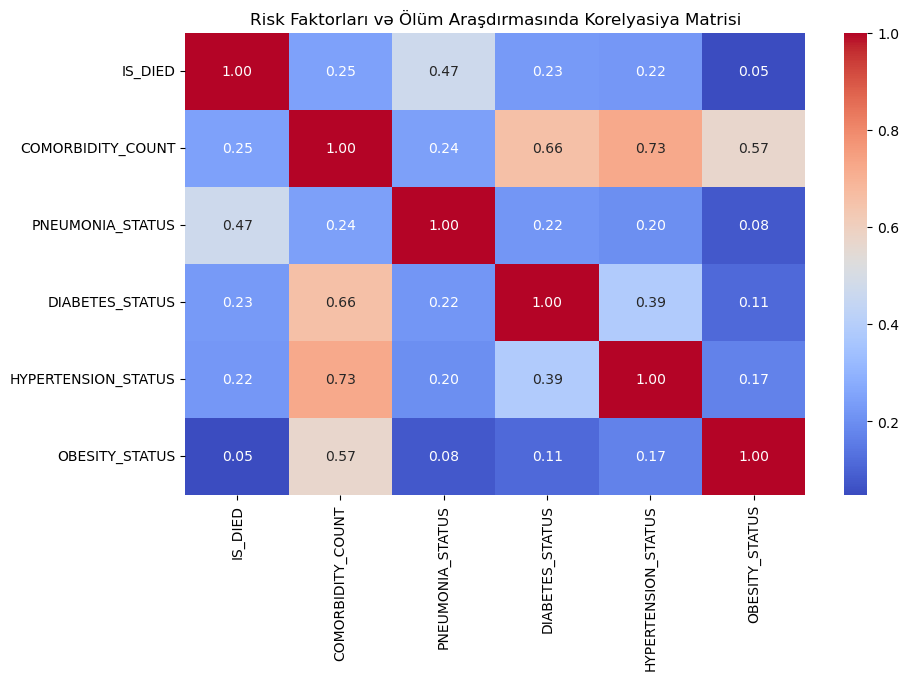

In [28]:
# Kateqorial dəyişənlərin binarlaşdırılması (0/1) və xətti əlaqələrin Heatmap ilə vizuallaşdırılması.

corr_cols=['IS_DIED', 'COMORBIDITY_COUNT', 'PNEUMONIA_STATUS', 
           'DIABETES_STATUS', 'HYPERTENSION_STATUS', 'OBESITY_STATUS']

df_corr = df[corr_cols].copy()
for col in corr_cols[2:]:
    df_corr[col] = (df_corr[col] == 'Yes').astype(int)

correlation_matrix=df_corr.corr()


# Korelyasiya Xəritəsinin Vizuallaşdırılması
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Risk Faktorları və Ölüm Araşdırmasında Korelyasiya Matrisi")
plt.show()